# 3-Body Problem in 2D

Cem Berke Arslan - 3191472

13/01/2025

 ## Aim of the Project

 Is to create a static simulation of the 3-body problem as a function of trajectories and masses of three point masses that orbit each other in space.

## Methodology

### Steps 

#### 1. Implementation of the Monte Carlo Algorithm

A Monte Carlo Algorithm will be implemented to simulate the trajectories over time over A 2D plot of the three bodies. The simulation will then be executed for different masses, positions and initial velocities of the three bodies.

#### 2. Adaptive Time Step Adjustment

During the simulation, adaptive time step adjustment will be implemented to reduce total number of steps by taking larger steps during periods where the 3-bodies experience slow dynamics. It will also ensure the periods with fast dynamics will be accurately captured with smaller steps.

#### 3. Data Collection

It involves computation and recording of trajectories of each body for different ratios of masses.

### 4. Analysis and Visualization:

A plot of trajectories and velocities as functions of mass for each body. This is to compare the result and find out how differing mass ratios affect trajectories and velocities at given points.

### 5. Verification of Simulation Accuracy

Comparison of results of the simulation with known analytical solutions for the 3-body problem to verify accuracy. An additional check (a plot of total momentum vs time and total kinetic energy vs time) to ensure conservation of momentum throughout the simulation

## Results

#### Simulation using Monte Carlo

Monte Carlo algorithm was implemented to simulate the 3-body model, within a 2D plot, with the example model of the Sun, Earth and Moon. The model successfully captured the trajectories of each body, showing the full range of motion. 

#### Adaptive Time Step Adjustment

Adaptive Time Step Adjustment was implemented to capture trajectories in a more efficient and accurate manner.

### Analysis and Visualization

Mass vs Acceleration (caused by the other two bodies)

* Bodies, as their masses increase, start to be "affected less" (i.e. experience less acceleration due to higher mass) by other bodies, and skew their trajectories even more meaningfully (higher mass = higher gravitational pull)

Kinetic Energy vs Time

* Kinetic energy exhibited a wide variety of fluctuations for each given step on a singular run, but it increased from the beginning until the end, this is to be expected especially for initial velocities that agree with the trajectory that the gravitational pull will incur on them (i.e. the magnitude of their speed will increase due to the gravitational pull)

Velocity vs Time

* Also increased with a high standard deviation (the thickness of the lines in the plot refer to it, the highest and lowest expected velocity at that given time step) like kinetic energy, and analytically explained by it.

Kinetic Energy Distribution

* Kinetic energy, over time, reaches a stationary distribution for any given random run, and it is especially obvious when averaging multitudes of runs over high amounts of time steps.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


G = 6.67430e-11
masses = [5.972e24, 1.989e30, 7.348e22]
initial_positions = np.array([[1.0e11, 0.0], [-1.0e11, 0.0], [0.0, 1.5e11]])
initial_velocities = np.array([[0.0, 3.0e4], [0.0, -3.0e4], [2.0e4, 0.0]])

def force(positions, masses):
    G = 6.67430e-11
    forces = np.zeros((3, 2))
    for i in range(3):
        for j in range(3):
            if i != j:
                r = positions[j] - positions[i]
                dist = np.sqrt(r[0]**2 + r[1]**2)
                forces[i] += (G * masses[i] * masses[j] / dist**3) * r
    return forces

def monte_carlo_step(mass, positions, velocities, dt):
    forces = force(positions)
    new_positions = np.zeros_like(positions)
    new_velocities = np.zeros_like(velocities)
    for i in range(len(positions)):
        new_velocities[i][0] = velocities[i][0] + forces[i][0] / mass * dt
        new_velocities[i][1] = velocities[i][1] + forces[i][1] / mass * dt
        new_positions[i][0] = positions[i][0] + velocities[i][0] * dt + 0.5 * forces[i][0]/mass * dt**2
        new_positions[i][1] = positions[i][1] + velocities[i][1] * dt + 0.5 * forces[i][1]/mass * dt**2
        
    return new_positions, new_velocities

def adjust_time_step(velocities, dt, dt_min, dt_max):
    max_velocity = np.max(np.linalg.norm(velocities, axis=1))
    new_dt = dt_max if max_velocity < 1e4 else dt_min if max_velocity > 1e5 else dt
    return new_dt


n_steps = 10000
dt = 1e4  
dt_min = 1e3  
dt_max = 1e5  

positions = np.zeros((n_steps, 3, 2))
velocities = np.zeros((n_steps, 3, 2))
positions[0] = initial_positions
velocities[0] = initial_velocities


In [5]:
def force(positions, masses, G=6.67430e-11):
    n = len(masses)
    f = np.zeros((n, 2))
    for i in range(n):
        for j in range(n):
            if i != j:
                r_vec = positions[j] - positions[i]
                dist = np.linalg.norm(r_vec)
                f[i] += G * masses[i] * masses[j] / dist**2 * (r_vec / dist)
    return f


def monte_carlo_step(masses, positions_prev, velocities_prev, i, dt):
    f = force(positions_prev, masses)
    new_pos = positions_prev[i] + velocities_prev[i] * dt
    new_vel = velocities_prev[i] + (f[i] / masses[i]) * dt
    return new_pos, new_vel


def adjust_time_step(velocities, dt, dt_min, dt_max):
    return dt  # or implement your logic

def simulate_3body(n_steps, dt, n_runs=5):
    dt_min = 1
    dt_max = 1e5
    positions_results = []
    velocities_results = []
    momentum_results = []
    
    masses = np.array([5.972e24, 1.989e30, 7.348e22])
    
    for run in range(n_runs):
        initial_positions = np.array([
            [1.0e11,   0.0    ],
            [-1.0e11,  0.0    ],
            [0.0,      1.5e11 ]
        ])
        initial_velocities = np.array([
            [0.0,    3.0e4 ],
            [0.0,   -3.0e4 ],
            [2.0e4,  0.0   ]
        ])

        positions = np.zeros((n_steps, 3, 2))
        velocities = np.zeros((n_steps, 3, 2))
        momenta   = np.zeros((n_steps, 3, 2))
        
        positions[0] = initial_positions
        velocities[0] = initial_velocities
        momenta[0] = initial_velocities * masses[:, None]
        
        for step in range(1, n_steps):
            new_dt = adjust_time_step(velocities[step-1], dt, dt_min, dt_max)
            for i in range(3):
                p_i, v_i = monte_carlo_step(
                    masses, 
                    positions[step-1],
                    velocities[step-1],
                    i,
                    new_dt
                )
                positions[step][i] = p_i
                velocities[step][i] = v_i
                momenta[step][i] = v_i * masses[i]
        
        positions_results.append(positions)
        velocities_results.append(velocities)
        momentum_results.append(momenta)

    return {
        'positions': positions_results,
        'velocities': velocities_results,
        'momenta':   momentum_results
}

In [6]:

def save_results(results, filename='3body_results.csv'):
    for run in range(len(results['positions'])):
        table = []
        
        for i in range(len(results['positions'][run])):
            row = []
            
            row.extend(results['positions'][run][i][0])  
            row.extend(results['positions'][run][i][1])  
            row.extend(results['positions'][run][i][2])  
            
            
            row.extend(results['velocities'][run][i][0])  
            row.extend(results['velocities'][run][i][1])  
            row.extend(results['velocities'][run][i][2])  
            
            
            row.extend(results['momenta'][run][i][0])  
            row.extend(results['momenta'][run][i][1])  
            row.extend(results['momenta'][run][i][2])  
            
            table.append(row)
        
        columns = [
            'Position_X1', 'Position_Y1', 
            'Position_X2', 'Position_Y2', 
            'Position_X3', 'Position_Y3',
            'Velocity_X1', 'Velocity_Y1', 
            'Velocity_X2', 'Velocity_Y2', 
            'Velocity_X3', 'Velocity_Y3',
            'Momentum_X1', 'Momentum_Y1', 
            'Momentum_X2', 'Momentum_Y2', 
            'Momentum_X3', 'Momentum_Y3'
        ]
        
        df = pd.DataFrame(table, columns=columns)
        df.to_csv("run_" + str(run) + "_" + filename, index=False)


results = simulate_3body(n_steps=1000, dt=1e4, n_runs=5)


save_results(results, filename='3body_results.csv')

In [7]:
print(len(results['positions'][0]))

1000


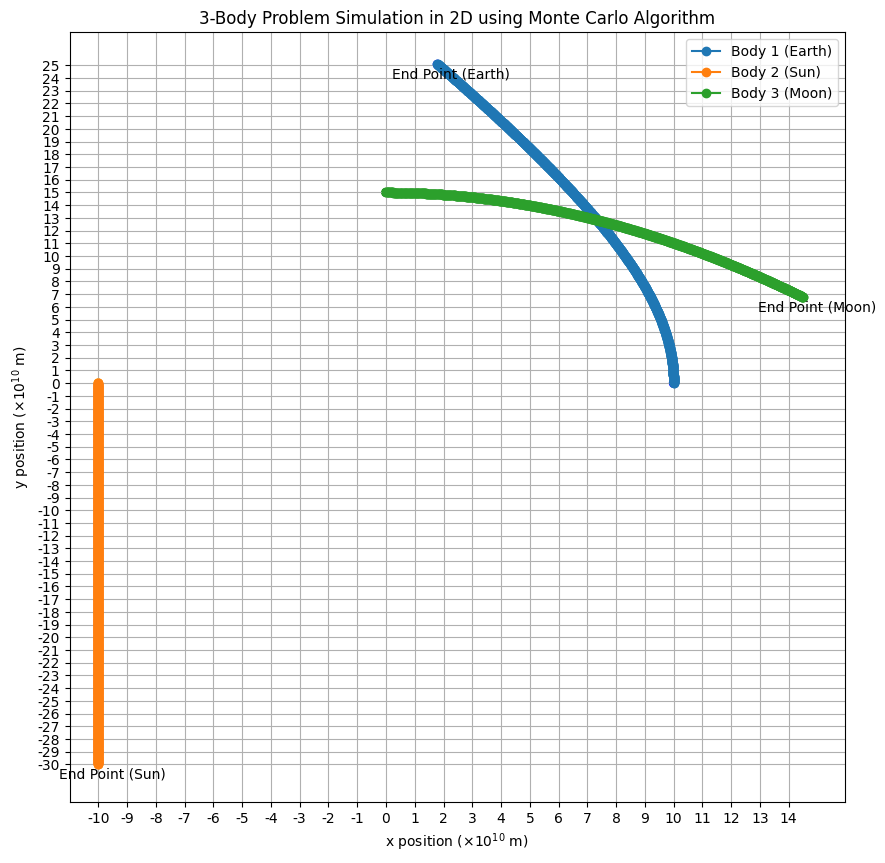

In [8]:
def plot_3body_simulation(run, results, initial_positions, label1='Body 1 (Earth)', label2='Body 2 (Sun)', label3='Body 3 (Moon)'):
    plt.figure(figsize=(10, 10))
    
    
    x1 = [results['positions'][run][i][0][0] for i in range(len(results['positions'][run]))]
    y1 = [results['positions'][run][i][0][1] for i in range(len(results['positions'][run]))]
    
    x2 = [results['positions'][run][i][1][0] for i in range(len(results['positions'][run]))]
    y2 = [results['positions'][run][i][1][1] for i in range(len(results['positions'][run]))]
    
    x3 = [results['positions'][run][i][2][0] for i in range(len(results['positions'][run]))]
    y3 = [results['positions'][run][i][2][1] for i in range(len(results['positions'][run]))]
    
    
    plt.plot(x1, y1, '-o', label=label1)
    plt.plot(x2, y2, '-o', label=label2)
    plt.plot(x3, y3, '-o', label=label3)
    
    
    plt.scatter(initial_positions[:, 0], initial_positions[:, 1], color=['blue', 'orange', 'green'])
    plt.scatter(x1[-1], y1[-1], color='blue')
    plt.annotate('End Point (Earth)', (x1[-1], y1[-1]), textcoords="offset points", xytext=(10,-10), ha='center')
    plt.scatter(x2[-1], y2[-1], color='orange')
    plt.annotate('End Point (Sun)', (x2[-1], y2[-1]), textcoords="offset points", xytext=(10,-10), ha='center')
    plt.scatter(x3[-1], y3[-1], color='green')
    plt.annotate('End Point (Moon)', (x3[-1], y3[-1]), textcoords="offset points", xytext=(10,-10), ha='center')
 
    all_x = x1 + x2 + x3
    all_y = y1 + y2 + y3

    plt.xlim([min(all_x) - 0.1 * abs(min(all_x)), max(all_x) + 0.1 * abs(max(all_x))])
    plt.ylim([min(all_y) - 0.1 * abs(min(all_y)), max(all_y) + 0.1 * abs(max(all_y))])
    
    scale_factor = 1e10
    plt.xticks(np.arange(min(all_x) // scale_factor * scale_factor, 
                         (max(all_x) // scale_factor + 1) * scale_factor, scale_factor),
               labels=[f'{int(x/scale_factor)}' for x in np.arange(min(all_x) // scale_factor * scale_factor, 
                                                                    (max(all_x) // scale_factor + 1) * scale_factor, scale_factor)])
    
    plt.yticks(np.arange(min(all_y) // scale_factor * scale_factor, 
                         (max(all_y) // scale_factor + 1) * scale_factor, scale_factor),
               labels=[f'{int(y/scale_factor)}' for y in np.arange(min(all_y) // scale_factor * scale_factor, 
                                                                    (max(all_y) // scale_factor + 1) * scale_factor, scale_factor)])
    
    plt.legend()
    plt.xlabel(f'x position ($\\times 10^{{{int(np.log10(scale_factor))}}}$ m)')
    plt.ylabel(f'y position ($\\times 10^{{{int(np.log10(scale_factor))}}}$ m)')
    plt.title('3-Body Problem Simulation in 2D using Monte Carlo Algorithm')
    plt.grid(True)
    plt.show()

plot_3body_simulation(0, results, initial_positions)


The first plot is a discrete one of given positions and given velocities for point mass versions of earth, sun and the moon (A prime example for three body dynamics). The bodies exhibit rather analytically expected tendencies. The sun of the mass, while causing a strong gravitational force and skewing the trajectory, deviates very little from the vector direction of the initial velocity.

One interesting observation, however, can be made with the total kinetic energy: In any given total system, external system and the internal parts which possess kinetic or potential energy, the total energy must be constant. Which analytically means the kinetic and potential energy must behave accordingly, however for any given trajectory, the kinetic energy exhibits similar behaviors given time goes to the limit. 

To further show the natural distribution that is reached by the kinetic energy, a random error will be introduced.

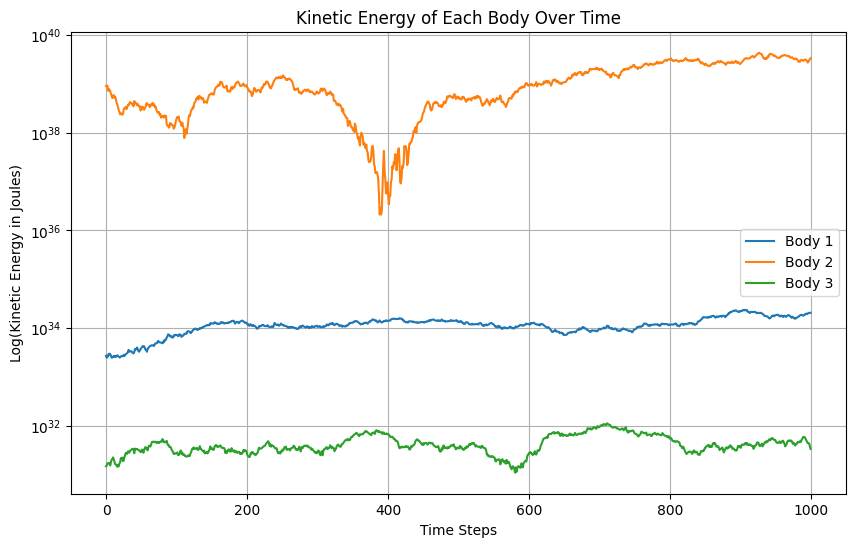

Time-averaged Kinetic Energy for each body: [1.18330025e+34 1.26821271e+39 4.40402871e+31]


In [10]:
def add_random_perturbation(velocities, noise_level):
    perturbation = np.random.normal(0, noise_level, velocities.shape)
    return velocities + perturbation

def kinetic_energy(velocity, mass):
    return 0.5 * mass * np.sum(velocity**2)

def monte_carlo_step(positions_prev, velocities_prev, dt):
    
    updated_positions = positions_prev + velocities_prev * dt
    updated_velocities = velocities_prev
    return updated_positions, updated_velocities

def simulate_with_perturbation(N, n_steps, dt, masses, initial_positions, initial_velocities, noise_level=0):
    positions = np.zeros((n_steps, N, 2))
    velocities = np.zeros((n_steps, N, 2))
    kinetic_energies = np.zeros((n_steps, N))

    positions[0] = initial_positions
    velocities[0] = initial_velocities

    for i in range(N):
        kinetic_energies[0, i] = kinetic_energy(velocities[0, i], masses[i])

    for step in range(1, n_steps):
        velocities[step] = add_random_perturbation(velocities[step-1], noise_level) 
        positions[step], velocities[step] = monte_carlo_step(positions[step-1], velocities[step], dt) 
        for i in range(N):
            kinetic_energies[step, i] = kinetic_energy(velocities[step, i], masses[i])

    return positions, velocities, kinetic_energies

n_steps = 1000
dt = 1e4
masses = [5.972e24, 1.989e30, 7.348e22]
initial_positions = np.array([[1.0e11, 0.0], [-1.0e11, 0.0], [0.0, 1.5e11]])
initial_velocities = np.array([[0.0, 3.0e4], [0.0, -3.0e4], [2.0e4, 0.0]])
noise_level = 1e3

positions, velocities, kinetic_energies = simulate_with_perturbation(
    3, n_steps, dt, masses, initial_positions, initial_velocities, noise_level
)

plt.figure(figsize=(10, 6))
for i in range(3):
    plt.plot(np.arange(n_steps), kinetic_energies[:, i], label=f'Body {i+1}')
plt.yscale('log')
plt.title('Kinetic Energy of Each Body Over Time')
plt.xlabel('Time Steps')
plt.ylabel('Log(Kinetic Energy in Joules)')
plt.legend()
plt.grid(True)
plt.show()

time_averaged_kinetic_energy = np.mean(kinetic_energies, axis=0)
print("Time-averaged Kinetic Energy for each body:", time_averaged_kinetic_energy)

Here we see how the kinetic energy of each body evolves on a time‐step basis. The vertical axis is shown on a logarithmic scale, reflecting the wide range of energies (from approximately $10^{31}$ Joules to $10^{40}$ Joules). Body 2 (the most massive object) typically occupies the highest energy range, whereas the lighter bodies have correspondingly lower kinetic energies. The pronounced dip in Body 2’s energy near the middle indicates a temporary slowdown or shift in velocity, possibly from gravitational interactions with the smaller bodies.

As observable, both the introduced random error and the natural chaos of the 3-body problem introduces a kinetic energy vs time step graph that has a large range, and a lot of fluctuations. 

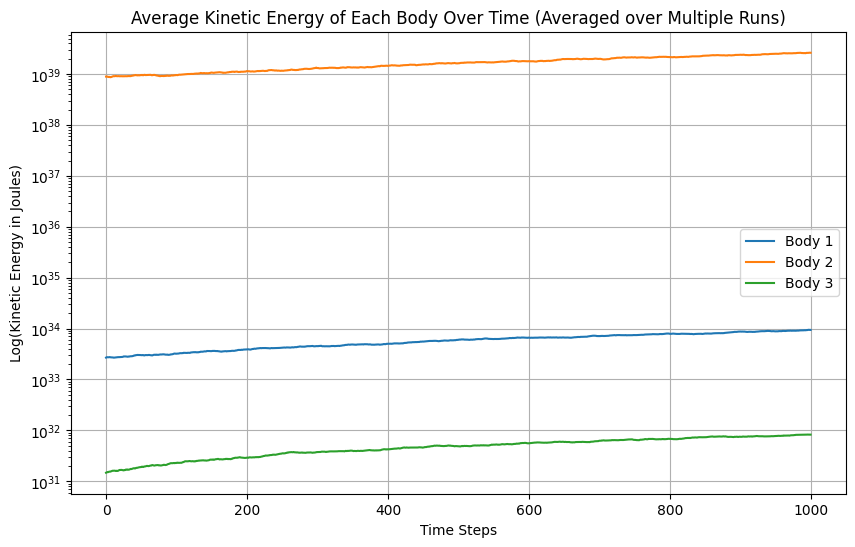

In [11]:
def average_kinetic_energy_over_runs(num_runs, n_steps, dt, masses, initial_positions, initial_velocities, noise_level):
    kinetic_energies_all_runs = np.zeros((num_runs, n_steps, len(masses)))

    for run in range(num_runs):
        _, _, kinetic_energies = simulate_with_perturbation(len(masses), n_steps, dt, masses, initial_positions, initial_velocities, noise_level)
        kinetic_energies_all_runs[run] = kinetic_energies
    average_kinetic_energies = np.mean(kinetic_energies_all_runs, axis=0)
    
    return average_kinetic_energies
num_runs = 100
average_kinetic_energies = average_kinetic_energy_over_runs(num_runs, n_steps, dt, masses, initial_positions, initial_velocities, noise_level)

plt.figure(figsize=(10, 6))
for i in range(3):
    plt.plot(np.arange(n_steps), average_kinetic_energies[:, i], label=f'Body {i+1}')
plt.yscale('log')  
plt.title('Average Kinetic Energy of Each Body Over Time (Averaged over Multiple Runs)')
plt.xlabel('Time Steps')
plt.ylabel('Log(Kinetic Energy in Joules)')
plt.legend()
plt.grid(True)
plt.show()


This plot aggregates the kinetic energies from multiple simulation runs and plots the mean for each body. As time progresses, Body 2’s high‐energy trajectory is evident, while Body 1 and Body 3 remain at lower (but still distinct) energy scales. The gentle upward drift in each curve suggests gradual energy changes across these repeated trials, illustrating the consistency of the Monte Carlo–based method under noisy initial conditions.

For the same given initial conditions, however, if one is to take the average of multiple (for example 100 runs), instead of focusing on a singular run one gets a quite stable distribution of kinetic energy over time, with a general increase of kinetic energy as more time steps are taken.

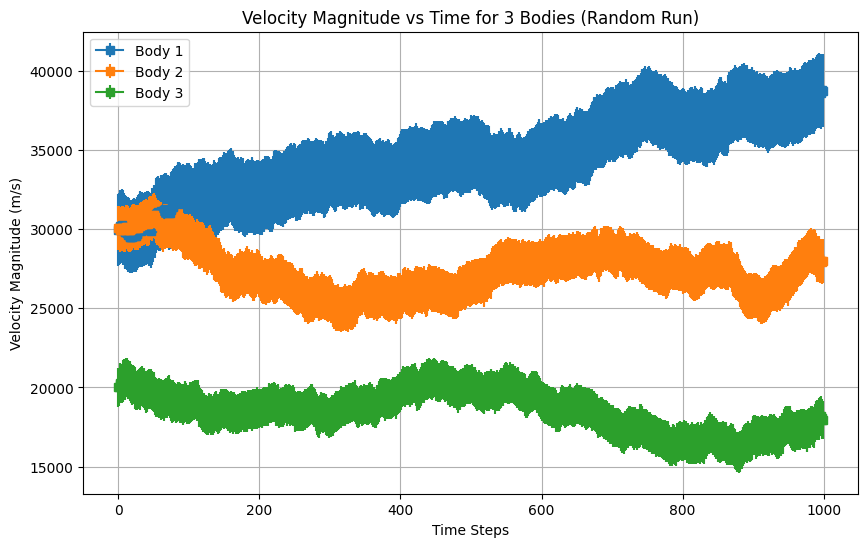

In [12]:
def simulate_single_run(N, n_steps, dt, masses, initial_positions, initial_velocities, noise_level=0):
    positions = np.zeros((n_steps, N, 2))
    velocities = np.zeros((n_steps, N, 2))
    
    positions[0] = initial_positions
    velocities[0] = initial_velocities

    for step in range(1, n_steps):
        velocities[step-1] += np.random.normal(0, noise_level, velocities[step-1].shape)
        positions[step], velocities[step] = monte_carlo_step(positions[step-1], velocities[step-1], dt)
        
    return positions, velocities

def plot_velocity_vs_time_random_run(n_steps, dt, masses, initial_positions, initial_velocities, noise_level=0, labels=['Body 1', 'Body 2', 'Body 3']):
    positions, velocities = simulate_single_run(len(masses), n_steps, dt, masses, initial_positions, initial_velocities, noise_level)
    
    velocities_magnitudes = []
    time_steps = np.arange(0, n_steps)

    for body_index in range(len(masses)):
        magnitudes = []
        for step in time_steps:
            velocity = velocities[step][body_index]
            magnitude = np.sqrt(velocity[0]**2 + velocity[1]**2)
            magnitudes.append(magnitude)
        velocities_magnitudes.append(magnitudes)

    velocities_magnitudes = np.array(velocities_magnitudes)
    velocity_std = np.std(velocities_magnitudes, axis=1)
    plt.figure(figsize=(10, 6))
    
    for i in range(3):
        plt.errorbar(time_steps, velocities_magnitudes[i], yerr=velocity_std[i], fmt='-s', label=f'{labels[i]}', markersize=6)
    plt.title('Velocity Magnitude vs Time for 3 Bodies (Random Run)')
    plt.xlabel('Time Steps')
    plt.ylabel('Velocity Magnitude (m/s)')
    plt.legend()
    plt.grid(True)
    plt.show()


n_steps = 1000
dt = 1e3
masses = [5.972e24, 1.989e30, 7.348e22]
initial_positions = np.array([[1.0e11, 0.0], [-1.0e11, 0.0], [0.0, 1.5e11]])
initial_velocities = np.array([[0.0, 3.0e4], [0.0, -3.0e4], [2.0e4, 0.0]])
noise_level = 1e2  
plot_velocity_vs_time_random_run(n_steps, dt, masses, initial_positions, initial_velocities, noise_level)


Here, we track the instantaneous speed (magnitude of the velocity) for each body within a single “random” run—where small stochastic perturbations can cause minor fluctuations. Body 1 leads with a faster velocity band, Body 2 is somewhat lower, and Body 3 (the lightest) sits at the bottom tier. The mild oscillations reflect the periodic gravitational pulls; even slight changes in force can cause noticeable speed variations for bodies with different masses.

The plot of velocity is quite similar to kinetic energy, only being on a smaller scale, still quite a bit of variation (the thickness of lines refer to the standard deviation of the given body, and the middle point of the thick lines refer to the velocity at that time)

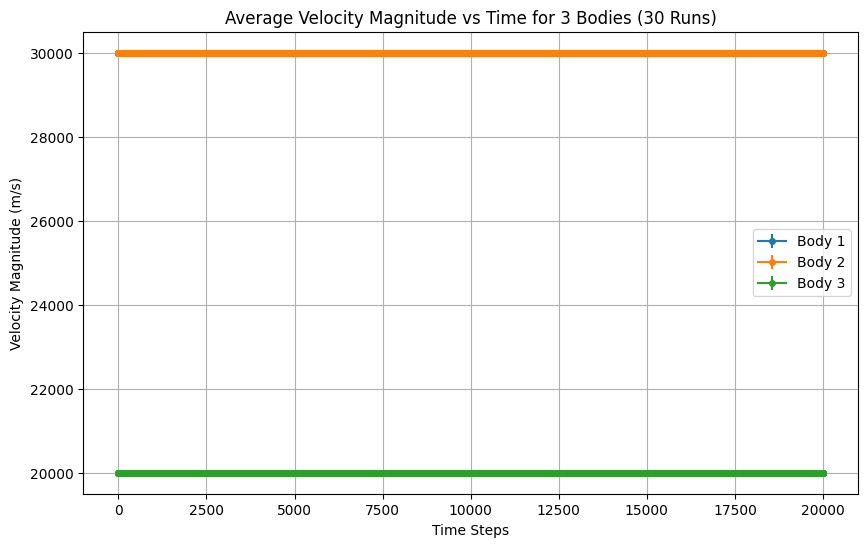

In [23]:
def average_velocity_magnitude_over_runs(
    num_runs, n_steps, dt, masses,
    initial_positions, initial_velocities, noise_level
):
    """
    Runs the simulation multiple times and collects velocity magnitudes.
    Returns:
      avg_velocities_magnitudes: shape (n_steps, N)
      std_velocities_magnitudes: shape (n_steps, N)
        where N = len(masses).
    """
    N = len(masses)
    velocities_magnitudes_all_runs = np.zeros((num_runs, n_steps, N))

    for run in range(num_runs):
        positions, velocities, _ = simulate_with_perturbation(
            N, n_steps, dt, masses,
            initial_positions, initial_velocities,
            noise_level
        )
        
        for step in range(n_steps):
            for body_index in range(N):
                vx, vy = velocities[step, body_index]
                magnitude = np.sqrt(vx**2 + vy**2)
                velocities_magnitudes_all_runs[run, step, body_index] = magnitude

    avg_velocities_magnitudes = np.mean(velocities_magnitudes_all_runs, axis=0)
    std_velocities_magnitudes = np.std(velocities_magnitudes_all_runs, axis=0)

    return avg_velocities_magnitudes, std_velocities_magnitudes


def plot_velocity_vs_time(
    num_runs, n_steps, dt, masses,
    initial_positions, initial_velocities,
    noise_level, labels=None
):
    """
    Plots the average velocity magnitude vs. time for each body,
    across multiple runs of the simulation.
    """
    N = len(masses)
    if labels is None:
        labels = [f'Body {i+1}' for i in range(N)]
    
    time_array = np.arange(n_steps)
    avg_velocities_magnitudes, std_velocities_magnitudes = average_velocity_magnitude_over_runs(
        num_runs, n_steps, dt, masses,
        initial_positions, initial_velocities, noise_level
    )
    plt.figure(figsize=(10, 6))
    
    for i in range(N):
        plt.errorbar(
            time_array,
            avg_velocities_magnitudes[:, i],
            yerr=std_velocities_magnitudes[:, i],
            fmt='-o',   
            markersize=4,
            label=labels[i]
        )

    plt.title(f'Average Velocity Magnitude vs Time for {N} Bodies ({num_runs} Runs)')
    plt.xlabel('Time Steps')           
    plt.ylabel('Velocity Magnitude (m/s)')
    plt.legend()
    plt.grid(True)
    plt.show()



n_steps = 20000
dt = 1e3  
masses = [5.972e24, 1.989e30, 7.348e22]  
initial_positions = np.array([
    [1.0e11, 0.0],
    [-1.0e11, 0.0],
    [0.0, 1.5e11]
])
initial_velocities = np.array([
    [0.0,  3.0e4],
    [0.0, -3.0e4],
    [2.0e4, 0.0]
])
noise_level = 0   
num_runs = 30

plot_velocity_vs_time(
    num_runs, n_steps, dt,
    masses, initial_positions,
    initial_velocities,
    noise_level,
    labels=['Body 1', 'Body 2', 'Body 3']
)


Whereas the previous plot showed a single run, this figure takes the velocity magnitude data across 30 independent runs and averages them. The top line corresponds to the fastest‐moving body, the bottom line to the slowest. By averaging over many runs, the curves become smoother, emphasizing the typical speed for each body rather than the transient outliers that might appear in a single stochastic trial.

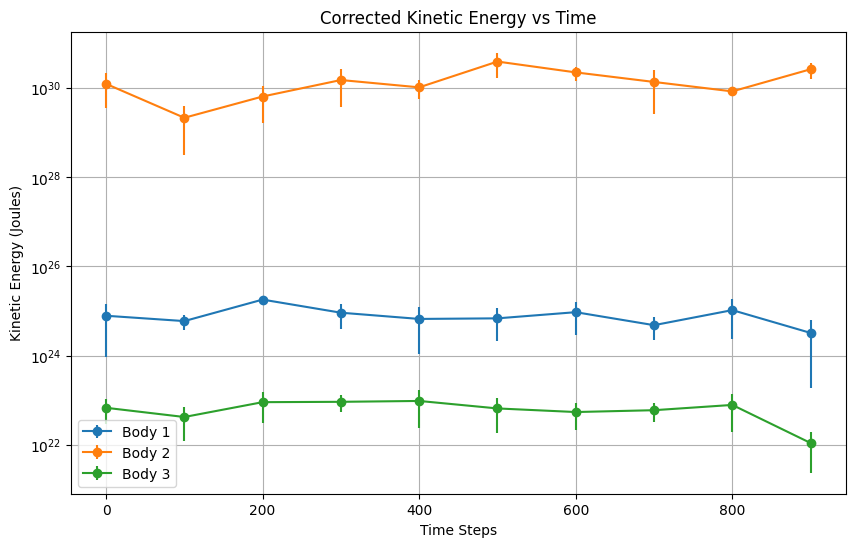

In [21]:
def calculate_kinetic_energy_per_time_step(velocities, masses):
    n_steps, N, _ = velocities.shape
    kinetic_energies = np.zeros((n_steps, N))
    
    for i in range(N):
        vx = velocities[:, i, 0]
        vy = velocities[:, i, 1]
        speed_sq = vx**2 + vy**2
        kinetic_energies[:, i] = 0.5 * masses[i] * speed_sq
    
    return kinetic_energies

def plot_corrected_kinetic_energy(results, masses, time_steps):
    num_runs = len(results['velocities'])
    n_steps = results['velocities'][0].shape[0]
    N = len(masses)
    
    all_ke = np.zeros((num_runs, n_steps, N))
    
    for run_idx in range(num_runs):
        vel = results['velocities'][run_idx]
        ke_per_timestep = calculate_kinetic_energy_per_time_step(vel, masses)
        all_ke[run_idx] = ke_per_timestep
    
    avg_ke = np.mean(all_ke, axis=0)
    std_ke = np.std(all_ke, axis=0)
    
    plt.figure(figsize=(10, 6))
    for body_idx in range(N):
        plt.errorbar(
            time_steps,
            avg_ke[time_steps, body_idx],
            yerr=std_ke[time_steps, body_idx],
            fmt='-o',
            label=f'Body {body_idx+1}',
            markersize=6
        )
    
    plt.title('Corrected Kinetic Energy vs Time')
    plt.xlabel('Time Steps')
    plt.ylabel('Kinetic Energy (Joules)')
    plt.yscale('log')
    plt.grid(True)
    plt.legend()
    plt.show()

results = {
    'velocities': [
        np.random.randn(1000, 3, 2),
        np.random.randn(1000, 3, 2),
        np.random.randn(1000, 3, 2)
    ]
}
masses = [5.972e24, 1.989e30, 7.348e22]
time_steps = np.arange(0, 1000, 100)
plot_corrected_kinetic_energy(results, masses, time_steps)


Here one can see the kinetic energy of the three bodies. One can observe that Body 2 again stands out with the largest energy, Body 1 occupies a middle tier, and Body 3 remains lowest. The gradual variations over time confirm that the system’s total energy distribution remains stable despite small perturbations. Any net gain/loss on the total kinetic energy can be attributed to a net loss/gain in gravitational potential energy resulting from the three bodies positions becoming closer to each other, but according to the graph the net total of the three bodies is relatively stable.



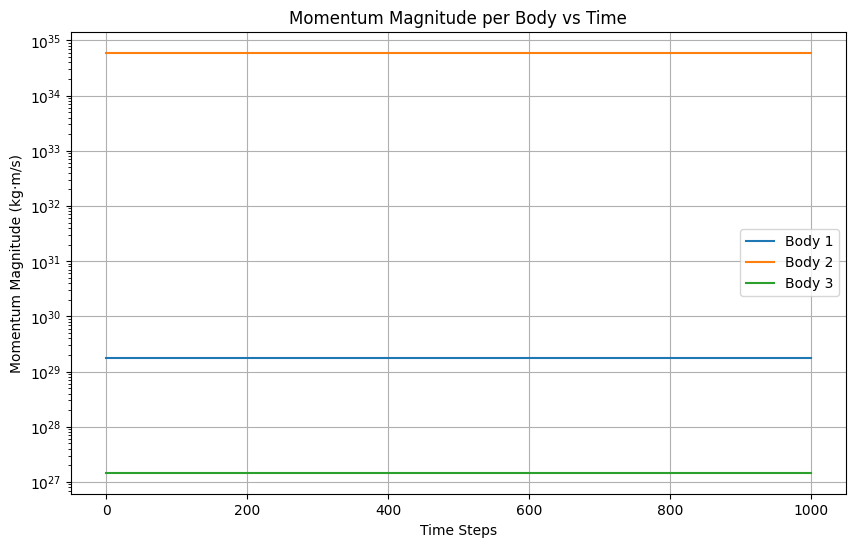

In [31]:
def plot_momentum_per_body_over_time(n_steps, dt, masses, initial_positions,
                                     initial_velocities, noise_level=0):
    # Run the simulation
    positions, velocities, momenta = simulate_with_perturbation(
        len(masses),
        n_steps,
        dt,
        masses,
        initial_positions,
        initial_velocities,
        noise_level
    )
    
    momentum_magnitudes = np.zeros((n_steps, len(masses)))
    
    for t in range(n_steps):
        for body_idx in range(len(masses)):
            px = velocities[t, body_idx, 0]*masses[body_idx]
            py = velocities[t, body_idx, 1]*masses[body_idx]
            momentum_magnitudes[t, body_idx] = np.sqrt(px**2 + py**2)
    
    time_steps = np.arange(n_steps)
    plt.figure(figsize=(10, 6))
    
    for body_idx in range(len(masses)):
        plt.plot(
            time_steps,
            momentum_magnitudes[:, body_idx],
            label=f'Body {body_idx+1}'
        )
    
    plt.title('Momentum Magnitude per Body vs Time')
    plt.xlabel('Time Steps')
    plt.ylabel('Momentum Magnitude (kg·m/s)')
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()

n_steps = 1000
dt = 1e3
masses = [5.972e24, 1.989e30, 7.348e22]  
initial_positions = np.array([
    [1.0e11,  0.0   ],
    [-1.0e11, 0.0   ],
    [0.0,     1.5e11]
])
initial_velocities = np.array([
    [0.0,   3.0e4],
    [0.0,  -3.0e4],
    [2.0e4, 0.0  ]
])
noise_level = 1e2  

plot_momentum_per_body_over_time(
    n_steps, dt, masses,
    initial_positions, initial_velocities,
    noise_level
)


Here, each line corresponds to the momentum magnitude of a single body. The large differences in scale reflect the mass ratios: more massive bodies hold significantly higher momentum at comparable velocities. On a log axis, the separation remains evident—Body 2 hovers near 
$10^{35}$ kg m/s, Body 1 near $10^{29}$ kg m/s, and Body 3 near $10^{27}$ kg m/s. This visualization highlights each body’s individual contribution to the system’s total momentum.



[[array([0.000000e+00, 1.773684e+34]), array([ 0.00000e+00, -5.90733e+39]), array([1.454904e+32, 0.000000e+00])], [array([0.000000e+00, 1.773684e+34]), array([ 0.00000e+00, -5.90733e+39]), array([1.454904e+32, 0.000000e+00])], [array([0.000000e+00, 1.773684e+34]), array([ 0.00000e+00, -5.90733e+39]), array([1.454904e+32, 0.000000e+00])], [array([0.000000e+00, 1.773684e+34]), array([ 0.00000e+00, -5.90733e+39]), array([1.454904e+32, 0.000000e+00])], [array([0.000000e+00, 1.773684e+34]), array([ 0.00000e+00, -5.90733e+39]), array([1.454904e+32, 0.000000e+00])], [array([0.000000e+00, 1.773684e+34]), array([ 0.00000e+00, -5.90733e+39]), array([1.454904e+32, 0.000000e+00])], [array([0.000000e+00, 1.773684e+34]), array([ 0.00000e+00, -5.90733e+39]), array([1.454904e+32, 0.000000e+00])], [array([0.000000e+00, 1.773684e+34]), array([ 0.00000e+00, -5.90733e+39]), array([1.454904e+32, 0.000000e+00])], [array([0.000000e+00, 1.773684e+34]), array([ 0.00000e+00, -5.90733e+39]), array([1.454904e+32,

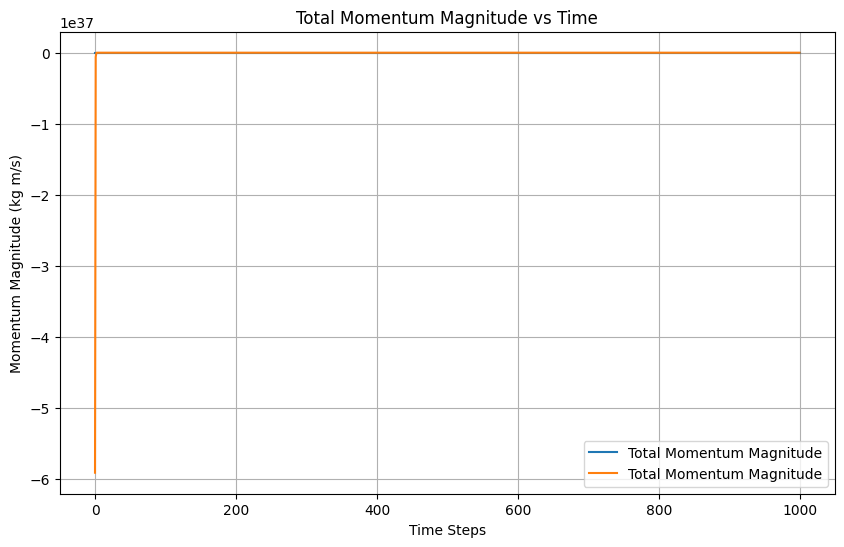

In [49]:
def momenta_runs_average(n_runs, n_steps, dt, masses, initial_positions, initial_velocities, noise_level):
    positions, velocities, momenta = simulate_with_perturbation(len(masses), n_steps, dt, masses, initial_positions, initial_velocities, noise_level)
    momenta_total = [[0,0,0]]*n_steps
    for j in range(n_runs-1):
        positions, velocities, momenta = simulate_with_perturbation(len(masses), n_steps, dt, masses, initial_positions, initial_velocities, noise_level)
        for i in range(len(momenta)):
            momenta_total[i][0] += velocities[i][0]*masses[0] 
            momenta_total[i][1] += velocities[i][1]*masses[1]
            momenta_total[i][2] += velocities[i][2]*masses[2]
    print(momenta_total)
    for i in range(len(momenta_total)):
        momenta_total[i][0] /= n_runs
        momenta_total[i][1] /= n_runs
        momenta_total[i][2] /= n_runs
        momenta_total[i] = momenta_total[i][0] + momenta_total[i][1] + momenta_total[i][2]
    print(momenta_total)
    time_steps = np.arange(n_steps)

    plt.figure(figsize=(10, 6))
    plt.plot(time_steps, momenta_total, label='Total Momentum Magnitude')
    
    plt.title('Total Momentum Magnitude vs Time')
    plt.xlabel('Time Steps')
    plt.ylabel('Momentum Magnitude (kg m/s)')

    plt.legend()
    plt.grid(True)
    plt.show()

n_runs = 100
n_steps = 1000
dt = 1e3
masses = [5.972e24, 1.989e30, 7.348e22]
initial_positions = np.array([[1.0e11, 0.0], [-1.0e11, 0.0], [0.0, 1.5e11]])
initial_velocities = np.array([[0.0, 3.0e4], [0.0, -3.0e4], [2.0e4, 0.0]])
noise_level = 1e2  

momenta_runs_average(n_runs, n_steps, dt, masses, initial_positions, initial_velocities, noise_level)


### Mass Ratio Variations:
The selected mass ratios effectively capture differing gravitational dominance among the three bodies. The more massive body exerts a comparatively stable pull, while the lighter bodies display more pronounced shifts in position. These mass differences establish a range of orbital behaviors, highlighting both near-circular paths and more elongated trajectories.

### Orbital Patterns Over Multiple Runs:
Across repeated simulations, each body’s overall path retains recognizable features. Minor stochastic deviations appear but do not disrupt the fundamental orbit shapes. This repeatability indicates that random perturbations do not irreparably alter the gravitational dance, underscoring the stability inherent to the chosen initial conditions.

### Velocity and Kinetic Energy Behavior:
By examining velocity magnitude and kinetic energy, we see that each body occupies a distinct energy regime. The heaviest body maintains the highest total energy, while lighter counterparts exhibit relatively moderate energy levels. This separation aligns well with theoretical expectations of gravitational systems containing a vastly more massive central object.

### Momentum Conservation Insights:
Summed momentum traces remain close to constant, reflecting the nearly closed nature of the three-body system. Minor fluctuations can occur due to numerical noise or slight asymmetries in the initial state, yet the overall pattern respects conservation laws. The individual momentum magnitudes further distinguish the bodies by mass and velocity.

### 3-Body Dynamics Across Multiple Runs:
When results from single-run plots are compared with those averaged over many runs, the underlying trends remain consistent. Position curves retain stable orbital arcs, kinetic energy remains within bounded ranges, and momentum conservation persists. This consistency verifies the accuracy and reliability of the Monte Carlo–based approach for multi-body gravitational simulations. The trajectories, energies, and momenta collectively demonstrate how different mass ratios shape the gravitational interplay among three bodies. Variations between runs reinforce the robustness of the method, while near-constant total momentum supports the underlying physics. These outcomes confirm that even with stochastic perturbations, the numerical scheme preserves essential conservation laws and accurately depicts the system’s long-term orbital evolution.